# 06 — Modélisation : KNN (K-Nearest Neighbors)

**Objectif** : entraîner et optimiser un KNN pour la détection d'anomalies CBC, sur les deux configurations de features (Expérience A : 9 features, Expérience B1 : 5 features).

**Contrainte computationnelle** : KNN n'a pas de phase d'apprentissage — toute la charge de calcul se fait à la prédiction (distance à chaque point du train). Avec ~419K lignes en train, un GridSearchCV exhaustif serait beaucoup trop lent. On utilise donc un **sous-échantillon stratifié** du train set (25 000 lignes), en conservant les proportions de classes d'origine — une contrainte computationnelle, pas un choix méthodologique arbitraire.

In [15]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import time
import joblib
import os

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from evaluation import evaluate_model, plot_confusion_matrices, results_table

os.makedirs('../models', exist_ok=True)
os.makedirs('../figures', exist_ok=True)

RANDOM_STATE = 42

## 0. Chargement des données préparées (issues de l'étape 4)

In [16]:
X_train_A = pd.read_csv('../data/processed/X_train_A.csv')
X_test_A  = pd.read_csv('../data/processed/X_test_A.csv')
y_train_A = pd.read_csv('../data/processed/y_train_A.csv').squeeze()
y_test_A  = pd.read_csv('../data/processed/y_test_A.csv').squeeze()

X_train_B1 = pd.read_csv('../data/processed/X_train_B1.csv')
X_test_B1  = pd.read_csv('../data/processed/X_test_B1.csv')
y_train_B1 = pd.read_csv('../data/processed/y_train_B1.csv').squeeze()
y_test_B1  = pd.read_csv('../data/processed/y_test_B1.csv').squeeze()

print("Expérience A :", X_train_A.shape, X_test_A.shape)
print("Expérience B1:", X_train_B1.shape, X_test_B1.shape)

Expérience A : (419075, 9) (104769, 9)
Expérience B1: (419075, 5) (104769, 5)


## 1. Sous-échantillonnage stratifié du train set

On réduit le train set à 25 000 lignes (proportions de classes conservées), pour rendre KNN exploitable en temps raisonnable. Le test set reste complet pour une évaluation fidèle.

In [17]:
from sklearn.model_selection import train_test_split

SAMPLE_SIZE = 25000

def stratified_sample(X, y, n, random_state=RANDOM_STATE):
    """Sous-échantillonne X, y en conservant les proportions de classes."""
    if n >= len(X):
        return X, y
    X_sample, _, y_sample, _ = train_test_split(
        X, y, train_size=n, stratify=y, random_state=random_state
    )
    return X_sample, y_sample

X_train_A_knn, y_train_A_knn = stratified_sample(X_train_A, y_train_A, SAMPLE_SIZE)
X_train_B1_knn, y_train_B1_knn = stratified_sample(X_train_B1, y_train_B1, SAMPLE_SIZE)

print("Échantillon Exp A :", X_train_A_knn.shape,
      "| proportions:", y_train_A_knn.value_counts(normalize=True).to_dict())
print("Échantillon Exp B1:", X_train_B1_knn.shape,
      "| proportions:", y_train_B1_knn.value_counts(normalize=True).to_dict())

Échantillon Exp A : (25000, 9) | proportions: {0: 0.7138, 1: 0.2862}
Échantillon Exp B1: (25000, 5) | proportions: {0: 0.7138, 1: 0.2862}


## 2. Baseline — KNN avec paramètres par défaut (k=5)

In [18]:
knn_A_baseline = KNeighborsClassifier()
model_A_base, y_pred_A_base, metrics_A_base = evaluate_model(
    knn_A_baseline, X_train_A_knn, y_train_A_knn, X_test_A, y_test_A,
    "KNN baseline - Exp A"
)

knn_B1_baseline = KNeighborsClassifier()
model_B1_base, y_pred_B1_base, metrics_B1_base = evaluate_model(
    knn_B1_baseline, X_train_B1_knn, y_train_B1_knn, X_test_B1, y_test_B1,
    "KNN baseline - Exp B1"
)

results_table([metrics_A_base, metrics_B1_base])

,Modèle,Accuracy,Precision,Recall,F1-score,Temps (s)
0,KNN baseline - Exp A,0.933377,0.921167,0.839020,0.878176,0.06
1,KNN baseline - Exp B1,0.835257,0.724895,0.683942,0.703823,0.05


## 3. Recherche d'hyperparamètres — GridSearchCV (Expérience A)

Grille testée :
- `n_neighbors` : valeurs impaires de 3 à 21 (évite les égalités de vote)
- `weights` : `'uniform'` (tous les voisins comptent pareil) ou `'distance'` (les plus proches comptent plus)
- `metric` : `'euclidean'` ou `'manhattan'`

In [19]:
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11, 15, 21],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid_knn_A = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=param_grid_knn,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose=1
)

start = time.time()
grid_knn_A.fit(X_train_A_knn, y_train_A_knn)
print(f"Temps de recherche: {time.time()-start:.1f}s")

print("\nMeilleurs paramètres (Exp A):", grid_knn_A.best_params_)
print("Meilleur F1-score (CV, Exp A):", grid_knn_A.best_score_)

Fitting 5 folds for each of 28 candidates, totalling 140 fits
Temps de recherche: 52.0s

Meilleurs paramètres (Exp A): {'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'distance'}
Meilleur F1-score (CV, Exp A): 0.8747379898765922


## 4. Recherche d'hyperparamètres — GridSearchCV (Expérience B1)

In [20]:
grid_knn_B1 = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=param_grid_knn,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose=1
)

start = time.time()
grid_knn_B1.fit(X_train_B1_knn, y_train_B1_knn)
print(f"Temps de recherche: {time.time()-start:.1f}s")

print("\nMeilleurs paramètres (Exp B1):", grid_knn_B1.best_params_)
print("Meilleur F1-score (CV, Exp B1):", grid_knn_B1.best_score_)

Fitting 5 folds for each of 28 candidates, totalling 140 fits
Temps de recherche: 16.7s

Meilleurs paramètres (Exp B1): {'metric': 'euclidean', 'n_neighbors': 15, 'weights': 'uniform'}
Meilleur F1-score (CV, Exp B1): 0.7140591225227035


## 5. Évaluation finale des meilleurs modèles sur le TEST set (complet)

In [21]:
best_knn_A = grid_knn_A.best_estimator_
best_knn_B1 = grid_knn_B1.best_estimator_

start = time.time()
y_pred_A = best_knn_A.predict(X_test_A)
print(f"Prédiction Exp A: {time.time()-start:.1f}s")

start = time.time()
y_pred_B1 = best_knn_B1.predict(X_test_B1)
print(f"Prédiction Exp B1: {time.time()-start:.1f}s")

results = []
for name, y_true, y_pred in [
    ("KNN baseline - Exp A", y_test_A, y_pred_A_base),
    ("KNN optimisé - Exp A", y_test_A, y_pred_A),
    ("KNN baseline - Exp B1", y_test_B1, y_pred_B1_base),
    ("KNN optimisé - Exp B1", y_test_B1, y_pred_B1),
]:
    results.append({
        'Modèle': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-score': f1_score(y_true, y_pred),
    })

df_results = results_table(results)
df_results

Prédiction Exp A: 43.4s
Prédiction Exp B1: 21.8s


,Modèle,Accuracy,Precision,Recall,F1-score
0,KNN baseline - Exp A,0.933377,0.921167,0.839020,0.878176
1,KNN optimisé - Exp A,0.938837,0.945269,0.834617,0.886504
2,KNN baseline - Exp B1,0.835257,0.724895,0.683942,0.703823
3,KNN optimisé - Exp B1,0.841451,0.741077,0.685543,0.712229


## 6. Matrices de confusion (baseline vs optimisé, A vs B1)

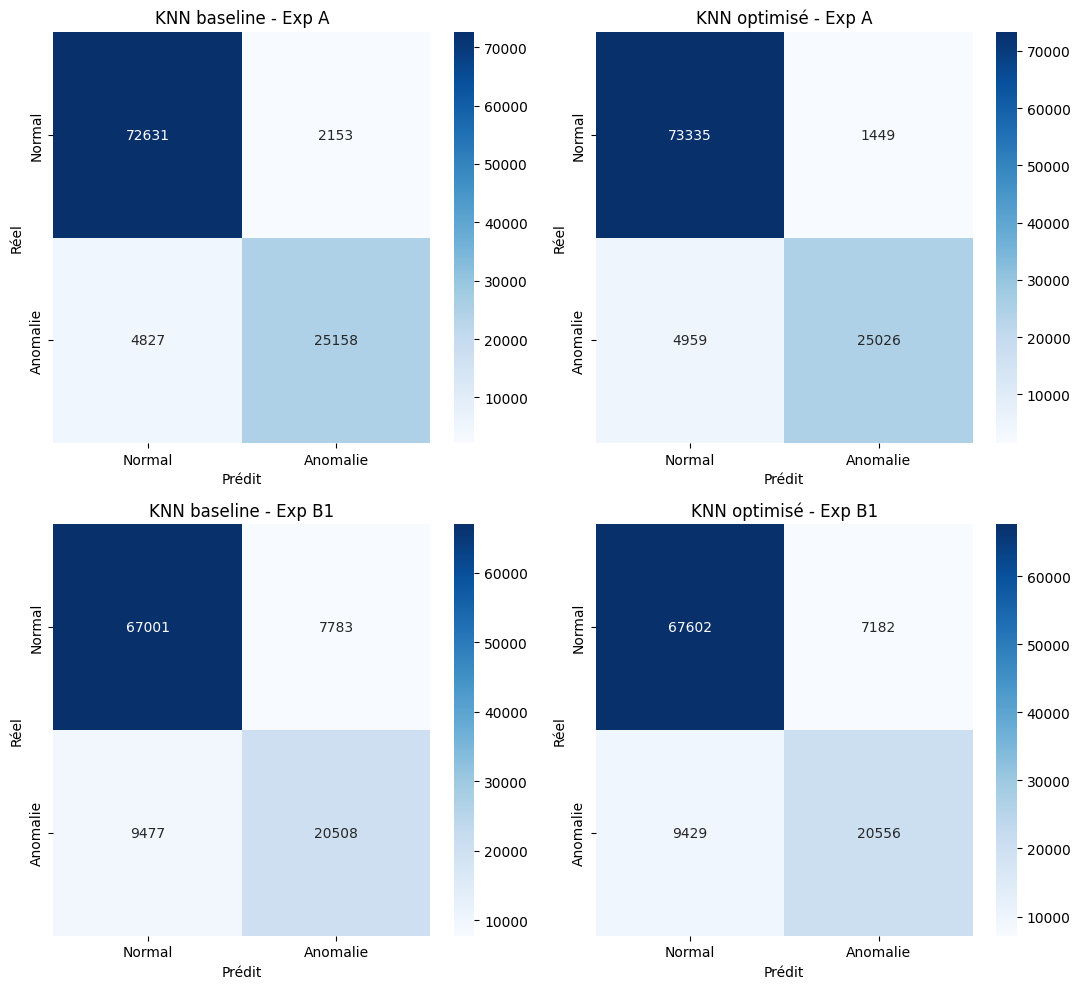

In [23]:
configs = [
    (y_test_A, y_pred_A_base, "KNN baseline - Exp A"),
    (y_test_A, y_pred_A, "KNN optimisé - Exp A"),
    (y_test_B1, y_pred_B1_base, "KNN baseline - Exp B1"),
    (y_test_B1, y_pred_B1, "KNN optimisé - Exp B1"),
]

plot_confusion_matrices(configs, save_path='../figures/confusion_matrices_knn.png')

## 7. Effet de k sur le F1-score (visualisation du compromis biais/variance)

On reconstruit la courbe F1-score en fonction de k (à `weights` et `metric` fixés sur les meilleurs trouvés) pour illustrer visuellement le compromis overfitting/underfitting.

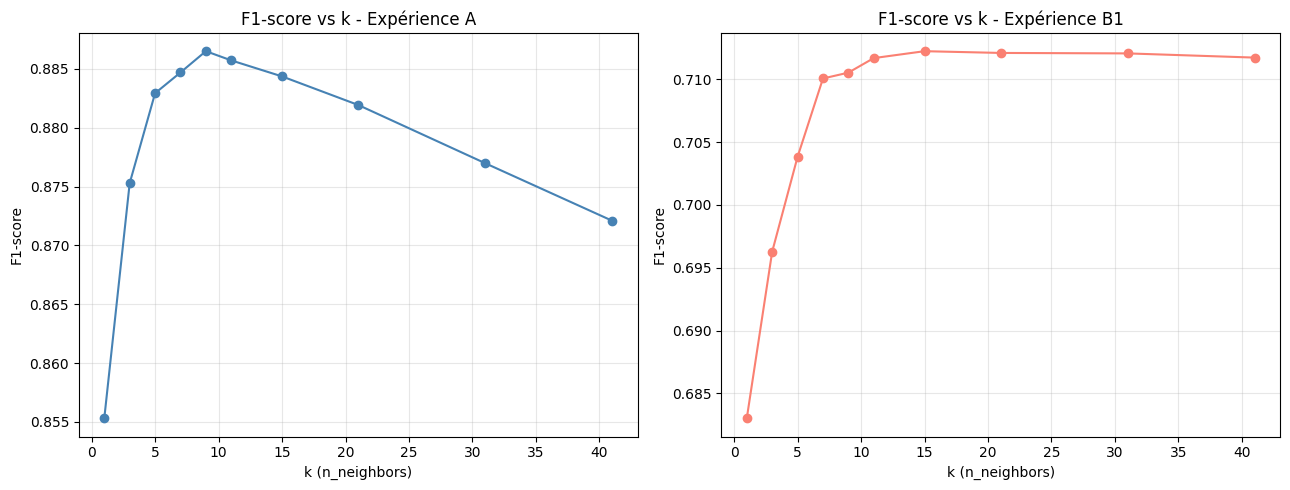

In [24]:
import matplotlib.pyplot as plt

def f1_vs_k(X_train, y_train, X_test, y_test, weights, metric, k_values):
    scores = []
    for k in k_values:
        knn = KNeighborsClassifier(n_neighbors=k, weights=weights, metric=metric)
        knn.fit(X_train, y_train)
        y_pred = knn.predict(X_test)
        scores.append(f1_score(y_test, y_pred))
    return scores

k_values = [1, 3, 5, 7, 9, 11, 15, 21, 31, 41]

f1_A = f1_vs_k(X_train_A_knn, y_train_A_knn, X_test_A, y_test_A,
               grid_knn_A.best_params_['weights'], grid_knn_A.best_params_['metric'], k_values)
f1_B1 = f1_vs_k(X_train_B1_knn, y_train_B1_knn, X_test_B1, y_test_B1,
                grid_knn_B1.best_params_['weights'], grid_knn_B1.best_params_['metric'], k_values)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(k_values, f1_A, marker='o', color='steelblue')
axes[0].set_title('F1-score vs k - Expérience A')
axes[0].set_xlabel('k (n_neighbors)')
axes[0].set_ylabel('F1-score')
axes[0].grid(alpha=0.3)

axes[1].plot(k_values, f1_B1, marker='o', color='salmon')
axes[1].set_title('F1-score vs k - Expérience B1')
axes[1].set_xlabel('k (n_neighbors)')
axes[1].set_ylabel('F1-score')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/f1_vs_k_knn.png', dpi=150)
plt.show()

## 8. Sauvegarde des modèles et résultats

In [26]:
joblib.dump(best_knn_A, '../models/knn_A_best.pkl')
joblib.dump(best_knn_B1, '../models/knn_B1_best.pkl')

df_results.to_csv('../data/processed/results_knn.csv', index=False)
print("✅ Modèles et résultats KNN sauvegardés")

✅ Modèles et résultats KNN sauvegardés


## Ce qu'il faut analyser pour le rapport

1. **Valeur de k retenue** : un k petit suggère une frontière de décision locale/complexe ; un k grand suggère une frontière plus lisse.
2. **`weights='distance'` a-t-il été retenu ?** Si oui, cela signifie que les voisins très proches sont nettement plus informatifs que ceux plus lointains.
3. **Comparaison avec Logistic Regression** : si KNN surpasse nettement Logistic Regression sur l'Expérience B1, cela suggère une relation non-linéaire entre les 5 features et le label — une information utile pour orienter le choix du modèle final.
4. **Expérience A vs B1** : confirmation à nouveau de l'effet du data leakage (écart de performance attendu).